In [17]:
import sys
sys.path.insert(0, '..')

In [18]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import interpax as ipx


In [19]:
wid = 80
oversample = 4

nwavels = 20
npoly=8

n_modes = 45
n_zernikes = 50

resolved_wid = 1

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes, turboklip="../data/turboklip.npz")

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

vects = np.load("../data/iterative_spectrum_basis_F110W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))



exposures_single = [
    exposure_from_file(ddir + 'n8zu67d0q_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F110W"), crop=wid, extra_bad=None, flatcorr=flatdir),
    # exposure_from_file(ddir + 'n8zu85ndq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]


223.9605 5.4
Version 4.1.1
37.5699


ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


In [20]:
exposures_single[0].hdr["TARGNAME"]

'HD181327'

In [21]:
params = {
    "spectrum": {},
    "primary_klip": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_tilt": {},
    "bias": {},
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*80)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.05, -0.75])*0.075
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181), 
        np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44)
    ])*0.075

    params["primary_klip"][exp.fit.get_key(exp, "primary_klip")] = np.zeros(7)
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros(n_zernikes)
    
    # np.array([ 5.68148267e+00, -1.67287293e+01, -7.21708323e+00,  1.29748075e+01,
    #      -1.41635507e+01, -5.44873825e+00,  1.84369297e+00,  8.72081299e+00,
    #      -8.21431272e+00, -3.57187675e+00, -1.17874964e+00,  2.03098313e+00,
    #      -2.16993244e+00,  2.52372386e+00,  2.15911644e+00, -1.48823821e+00,
    #      -1.52824454e+00,  1.34452541e+00, -9.76596237e-01,  1.43632166e+00,
    #       1.61910063e+00, -6.01588779e-01, -3.18966896e-01,  5.77287826e-01,
    #      -1.00543824e+00,  1.05612693e+00, -9.60698099e-01, -2.97138968e-01,
    #       4.98283891e-01, -3.29472784e-01, -1.63997721e+00, -3.17800448e-01,
    #       6.25666270e-01, -5.61004842e-01,  1.38721216e+00, -1.40934356e-02,
    #       1.27075546e+00,  1.47382301e+00,  1.00710782e+00, -8.17610523e-01,
    #       6.97838626e-02, -2.95474343e-01,  1.83301628e+00, -1.51965927e+00,
    #       6.73944656e-01,  1.31060882e+00, -9.88501178e-01, -5.61104670e-01,
    #       1.09037968e+00,  1.84147053e+00])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.

params = params | np.load("../data/optical_params.npy", allow_pickle=True)[()]
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

(45, 45) 45
(45, 45) 45
61.0395172317883


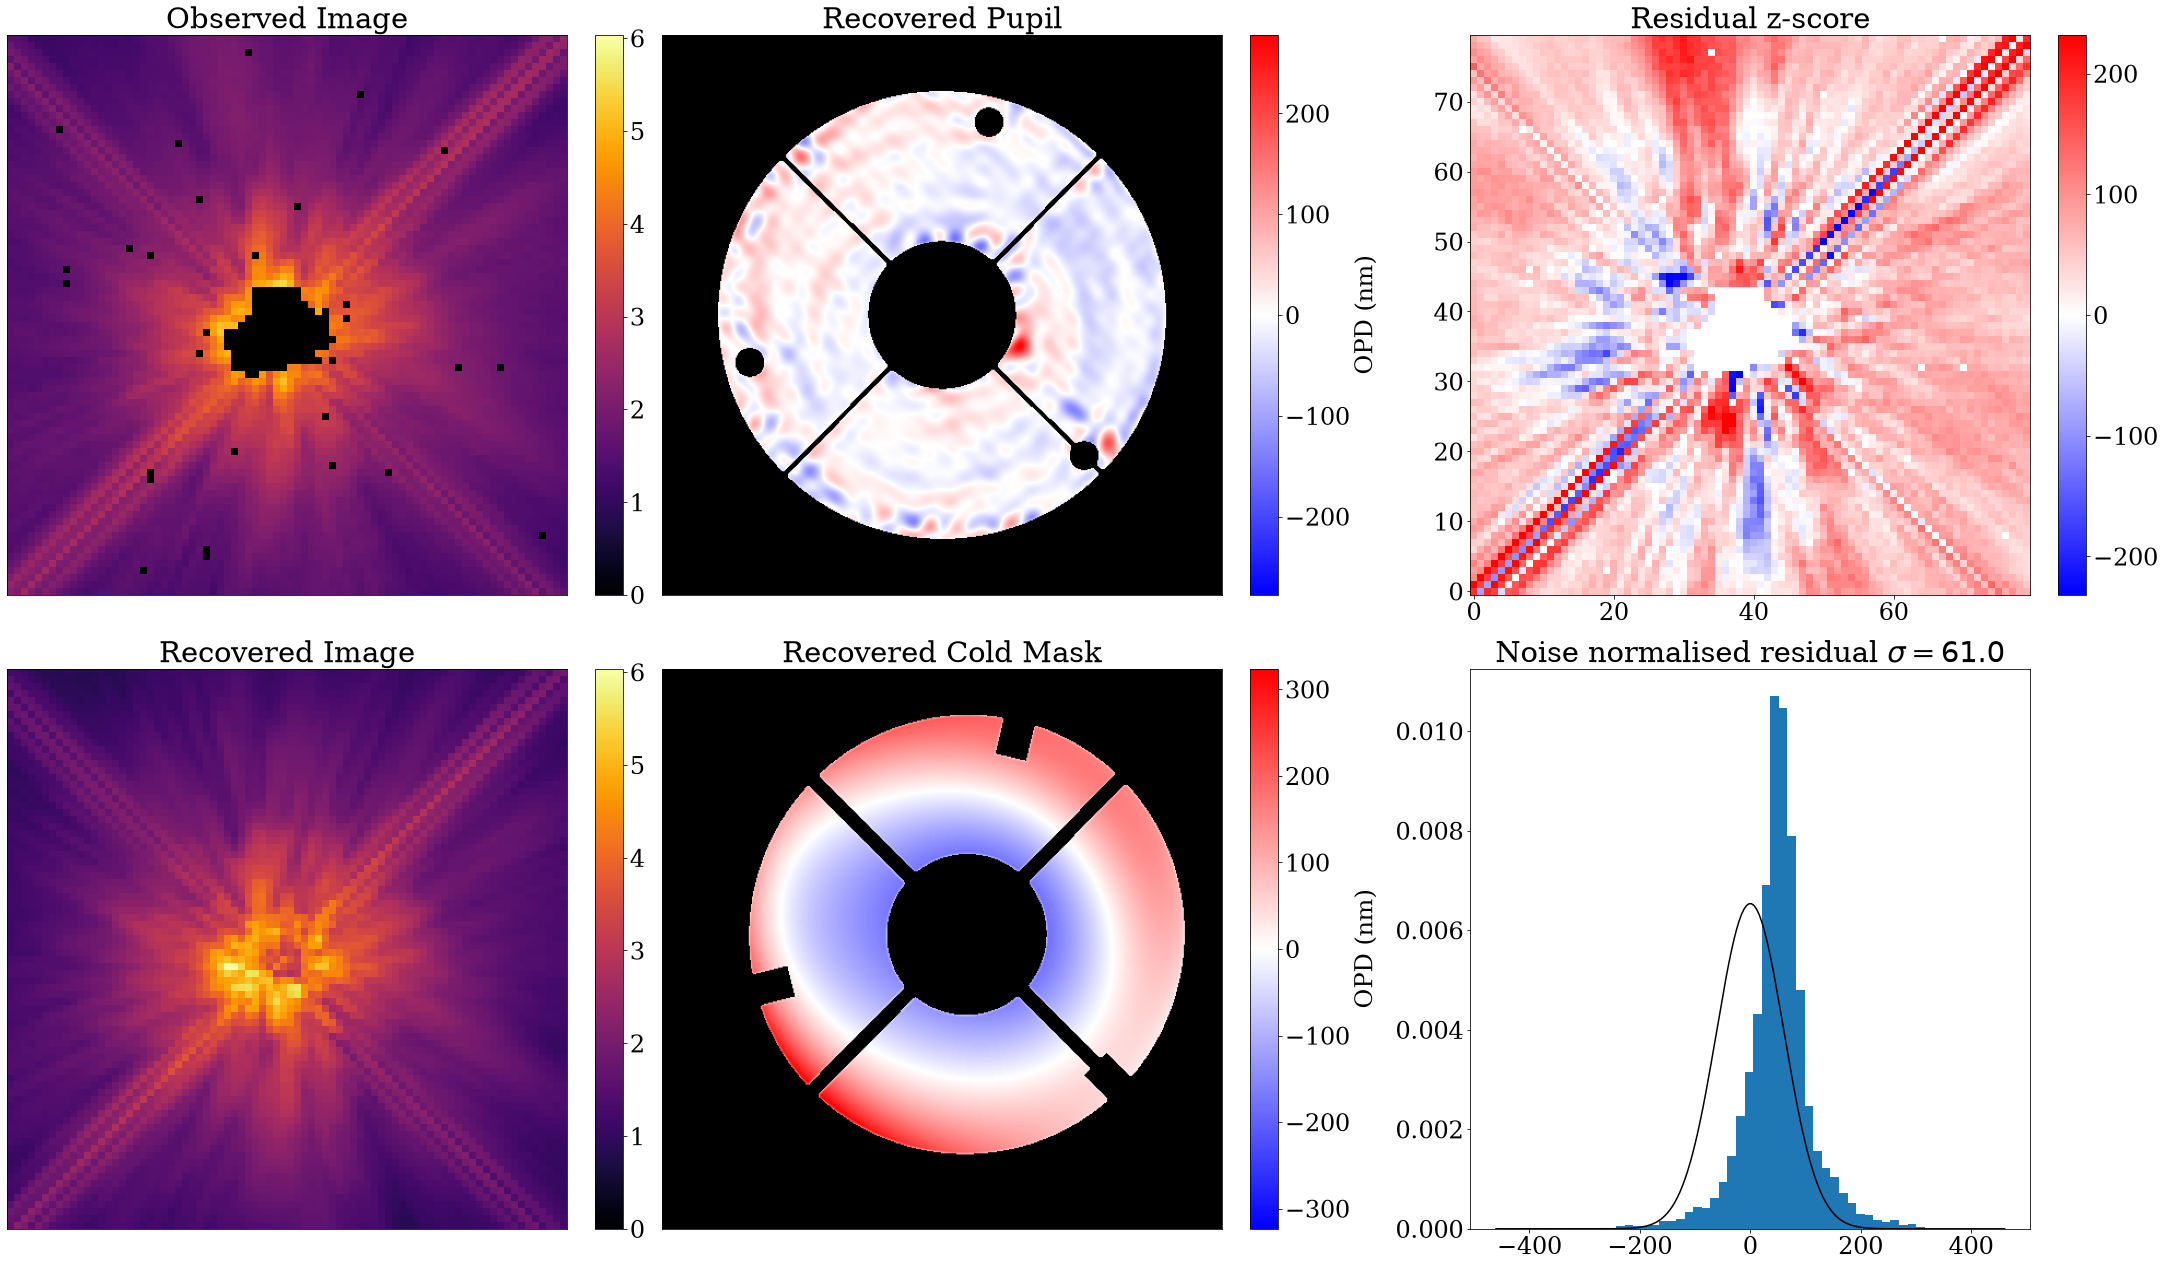

In [22]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=512, klip=True)

In [23]:
# stop

In [24]:
g = 5e-2


things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*1, 15.),
    "cold_mask_tilt": sgd(g*0.2, 0),

    # "bias": sgd(g*3, 40),
    # "cold_mask_shift": sgd(g*0.1, 50),

    # "primary_low": sgd(g*5, 70),
    # "primary_klip": sgd(g*2, 100),

    # "cold_mask_scale": sgd(g*5, 100),
    # "cold_mask_shear": sgd(g*10, 100),

    # # "primary_scale": sgd(g*5, 100),
    # "primary_shear": sgd(g*10, 100),

    # "occulter_radius": sgd(g*1., 120),
    # # "occulter_coeffs": sgd(g*1, 120),
    # # # "fnumber": sgd(g*2., 150),
}

In [25]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [26]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things_start, 50,
    precond_method="gn_exact", precond_kwargs=dict(chunk=16))

(45, 45) 45


  0%|          | 0/50 [00:00<?, ?it/s]

(45, 45) 45


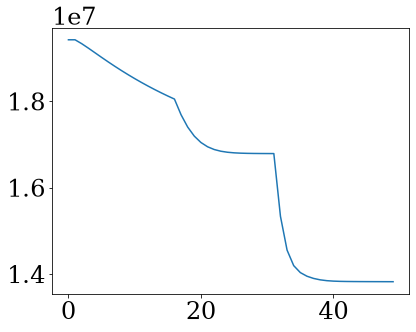

In [27]:
plt.plot(losses[:])

3
(45, 45) 45
(45, 45) 45
61.058178420619896


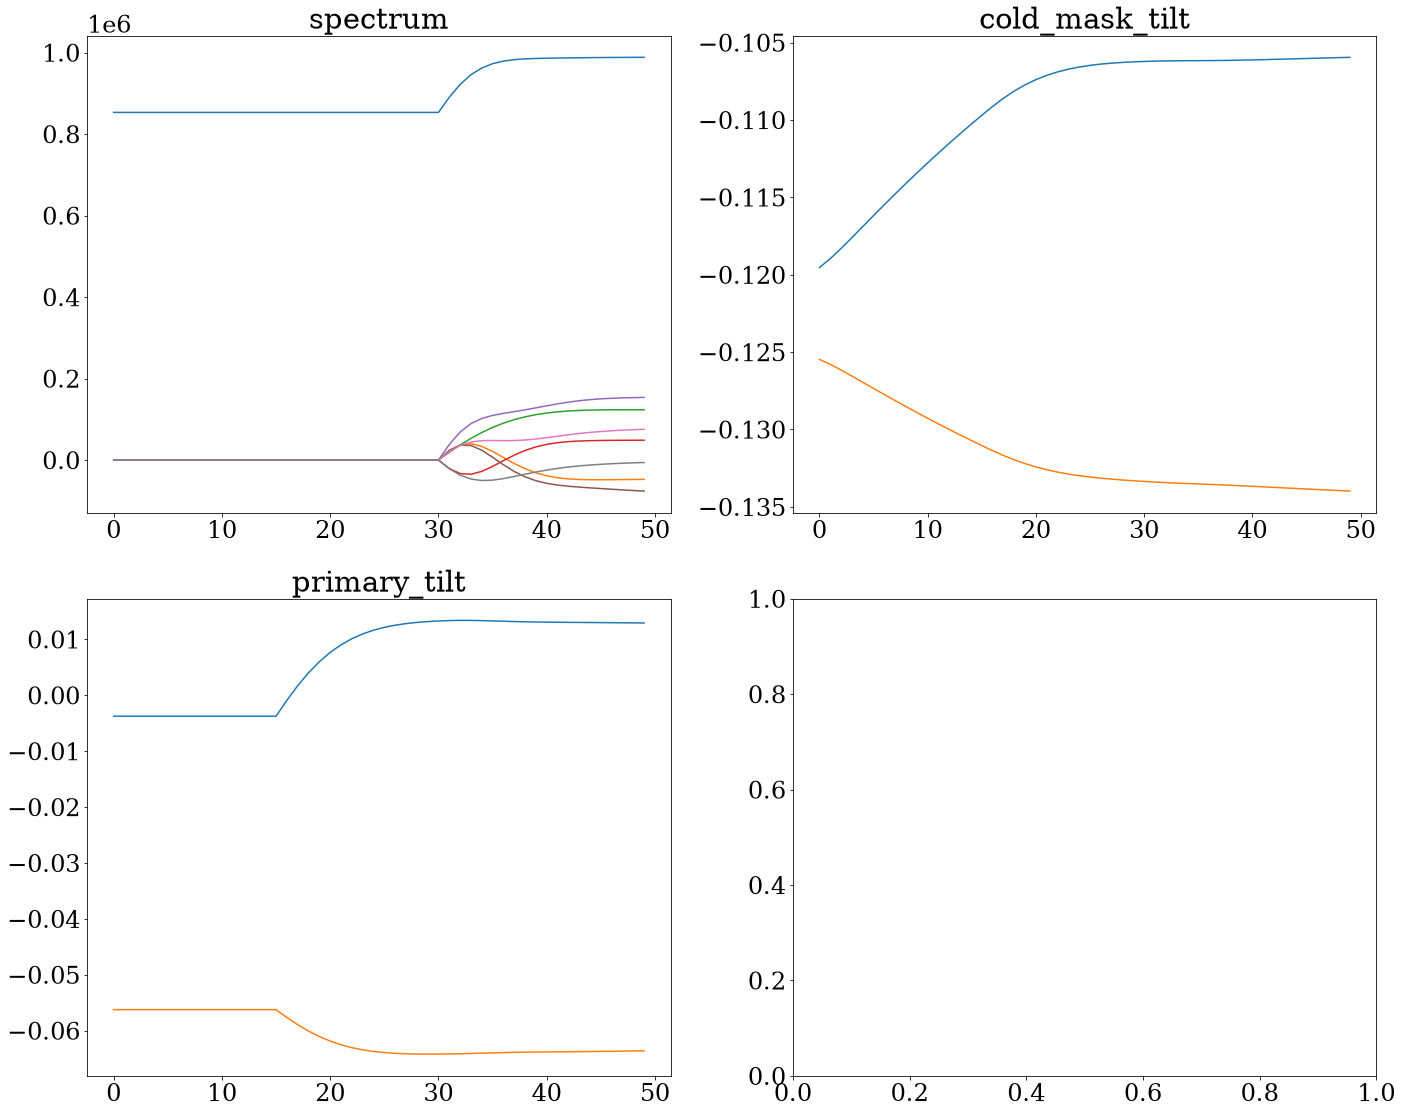

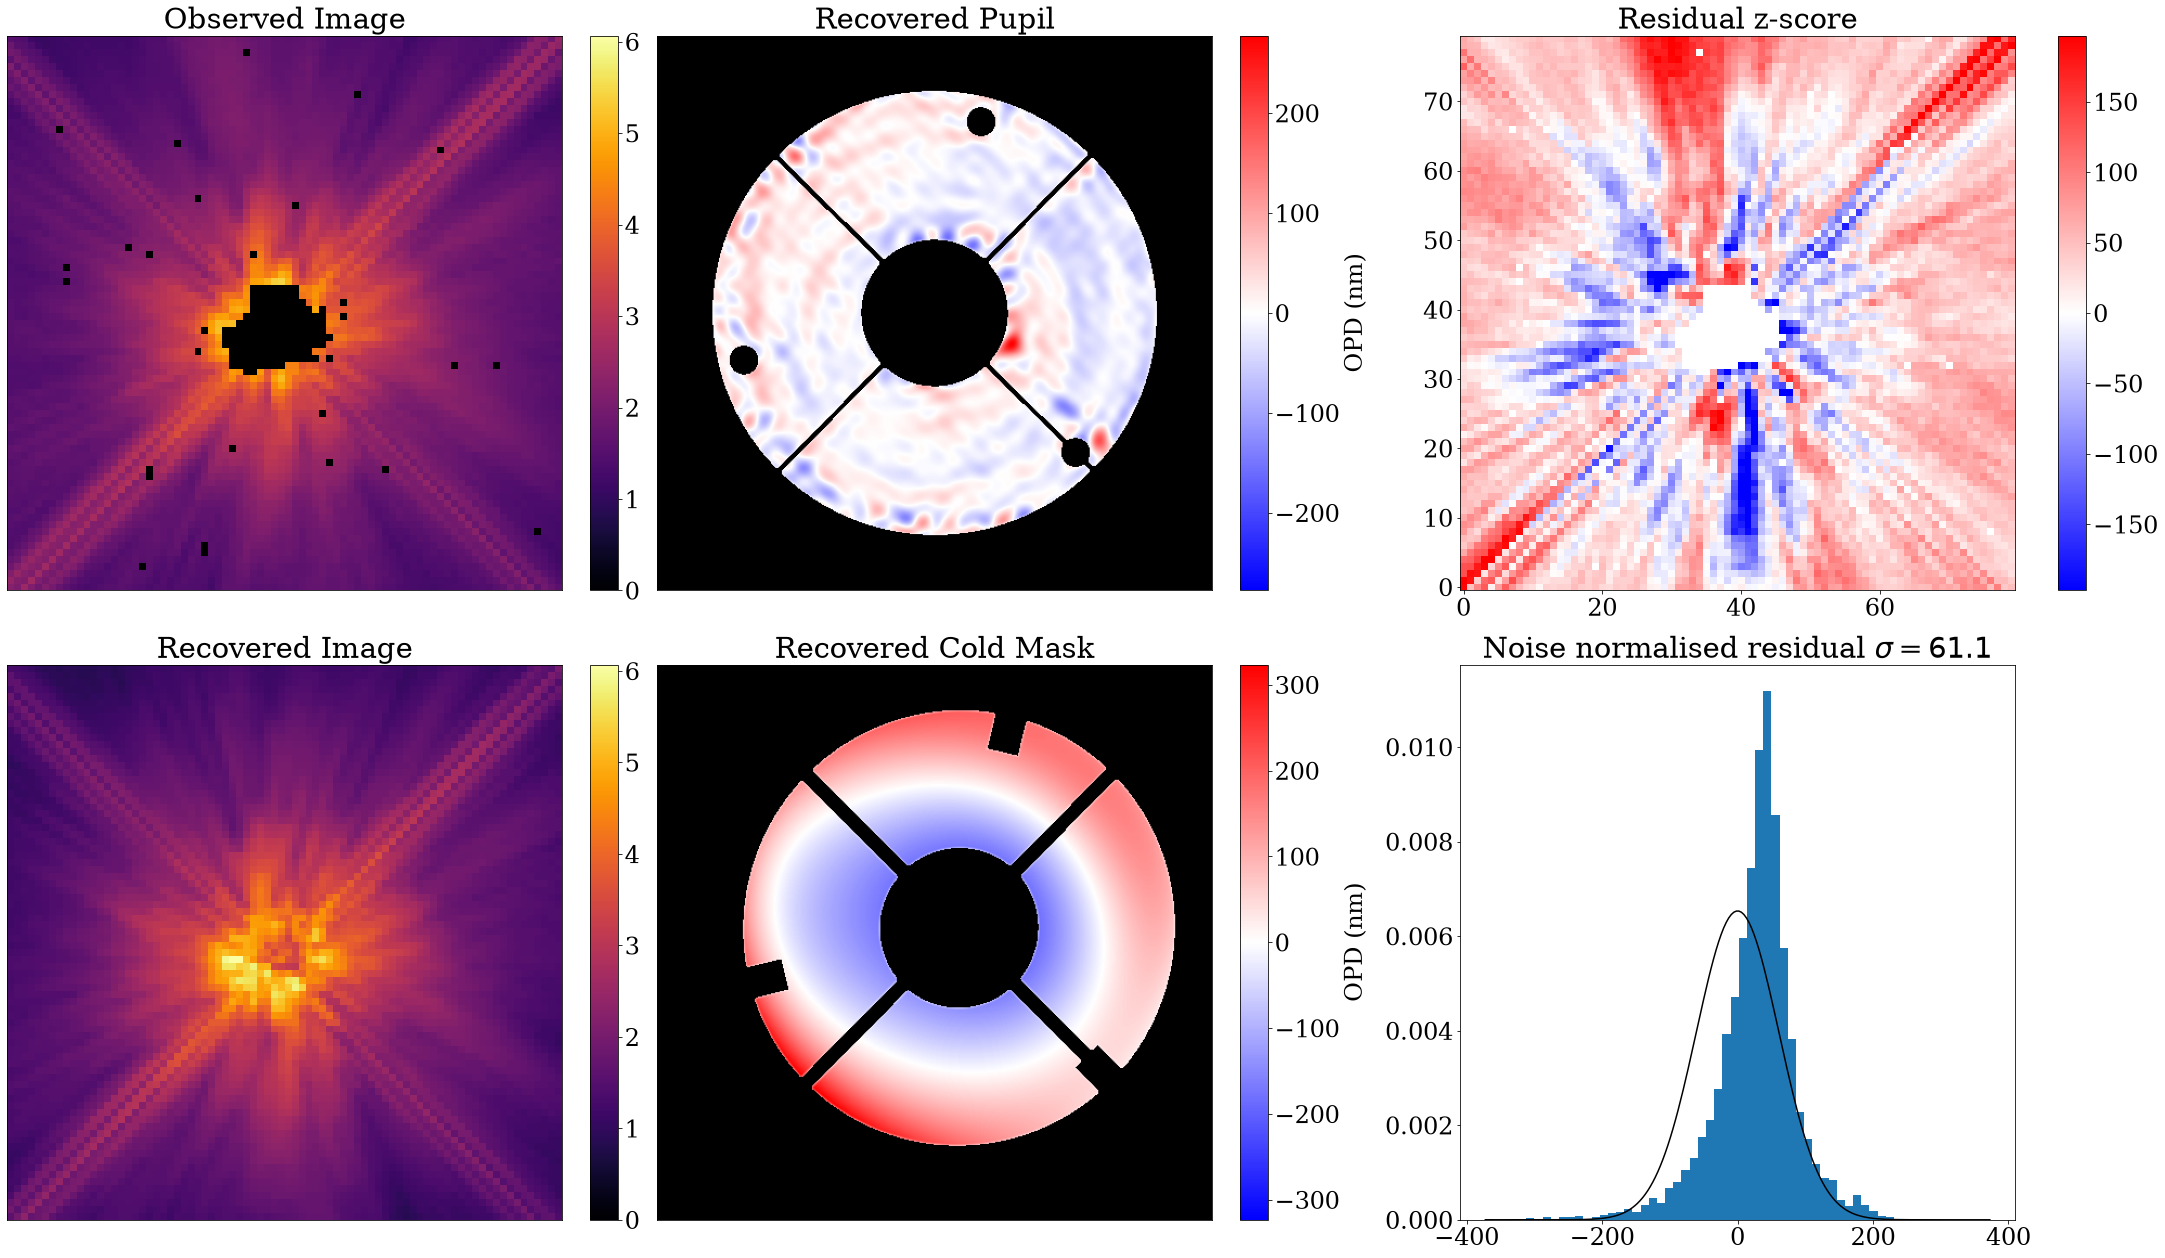

In [28]:
plot_params(params_history, list(things_start.keys()), xw = 2)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=99, quadrature=False, wf_size=512, klip=True)

In [29]:
params_history[-1]

{'cold_mask_tilt': {'global': Array([-0.10595323, -0.13398145], dtype=float64)},
 'primary_tilt': {'n8zu67d0q': Array([ 0.01292305, -0.06361159], dtype=float64)},
 'spectrum': {'HD181327_F110W': Array([988344.95083984, -47390.46145788, 123472.23350368,  48744.80335464,
         153794.72441838, -76110.93973616,  75513.39663863,  -5933.6892035 ],      dtype=float64)}}